# Transformers - Attention Is All You Need
### Date: 02/24/2025
### by Malik N. Mohammed

Transformer is a type of neural network arhictecture that learn context by tracking relationships in the sequential data. It is the backbone of the models like ChatGPT, BERT, and T5.

Unlike RNNs based models it doesn't process data one-by-one but instead looks at whole input at once (better for parallel processing)

Key concepts:
1. Word Embeddings and Positional Encoding/Embeddings
2. Self-Attention
3. Multi-Head Attention
4. Feed-Forward Network
5. Residual Connections + Layer Normalization

Transformer has two parts:
- **Encoder** (Processes input)
- **Decoder** (Generates the output)


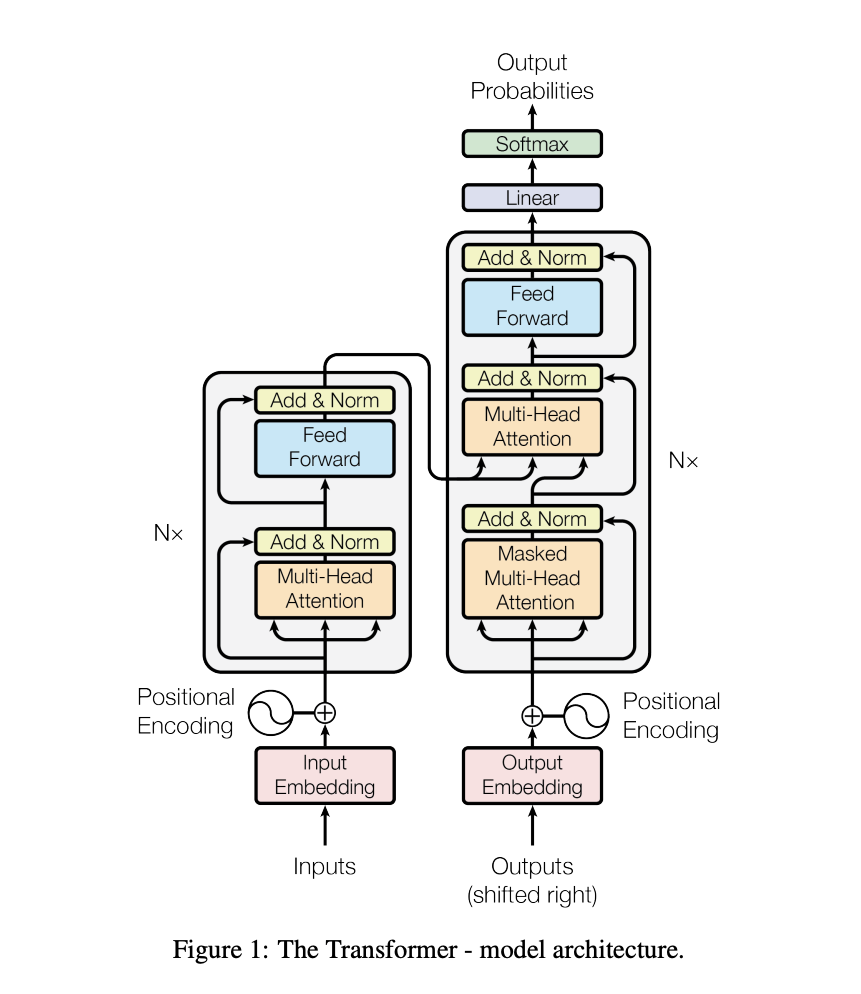


![Scaled Dot-Product Attention and Multi-Head Attention](https://machinelearningmastery.com/wp-content/uploads/2022/03/dotproduct_1.png)

$$\text{Scaled Dot-Product Attention(left) and Multi-Head Attention(right)}$$

### References:
- Vaswani, Ashish, et al. "[Attention is all you need](https://arxiv.org/abs/1706.03762)" Advances in neural information processing systems 30 (2017).
- https://blogs.nvidia.com/blog/what-is-a-transformer-model/

### Positional Embeddings/Encodings

To make use of the order of the sequence, the model needs some information about the relative or absolute position of the tokens in the sequence. So the positional encoding inject the sequence order into the model.

- Transformers process the input sequence in parallel.
- They have the same dimension $d_{model}$ as the embeddings for later summing.
- The paper used the **fixed sinusoidal encodings** (based on Fourier analysis) instead of the learnable embeddings (later used by BERT, etc)
- 

$$PE_{(pos, 2i)} = \sin (\frac{pos}{10000^{\frac{2i}{d_{model}}}})$$
$$PE_{(pos, 2i + 1)} = \cos (\frac{pos}{10000^{\frac{2i}{d_{model}}}})$$

Where:
- $pos$ = position in the sequence
- $i$ = dimension index of the embedding vector
- $d_{model}$ = total embedding diemsnion (e.g. 512 used in the "Attention is all you need" paper)
- $10000^{\frac{2i}{d_{model}}}$ = scaling factor to make different dimensions operate at different frequencies.


In [1]:
import torch
import math

In [2]:
sequence_length = 10
d_model = 512 # embedding dimension.

pos = torch.arange(sequence_length).reshape(-1, 1)

denominator = torch.pow(10000, -torch.arange(0, d_model, 2) / d_model)

pe = torch.zeros(sequence_length, d_model)
pe[:, 0::2] = torch.sin(pos * denominator)
pe[:, 1::2] = torch.cos(pos * denominator)

pe

tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
          0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  8.2186e-01,  ...,  1.0000e+00,
          1.0366e-04,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  9.3641e-01,  ...,  1.0000e+00,
          2.0733e-04,  1.0000e+00],
        ...,
        [ 6.5699e-01,  7.5390e-01,  4.5239e-01,  ...,  1.0000e+00,
          7.2564e-04,  1.0000e+00],
        [ 9.8936e-01, -1.4550e-01,  9.9067e-01,  ...,  1.0000e+00,
          8.2931e-04,  1.0000e+00],
        [ 4.1212e-01, -9.1113e-01,  6.7637e-01,  ...,  1.0000e+00,
          9.3297e-04,  1.0000e+00]])

### Self-attention

The attention is calculated as follows:

$$Attention(Q, K, V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$$

The reason why we divide the $QK^T$ by $\sqrt{d_k}$ is because if the $d_k$ is large then the dot product will have large variance leading to very small gradients after applying the softmax. To prevent this, we divide by this scaling factor to keep values stable.

If the dimension of query, key, and values are different then we need to perform additional multiplication to bring them to the desired dimension for further multiplication.

In [3]:
# Let's create weights for W_q, W_k and W_v

d_q, d_k, d_v = 128, 128, 128 # Generally we take same as the token dimension.
W_q = torch.rand((d_model ,d_k))
W_k = torch.rand((d_model ,d_k))
W_v = torch.rand((d_model ,d_v))

W_q, W_q.shape

(tensor([[0.3960, 0.8270, 0.7001,  ..., 0.6752, 0.8414, 0.5018],
         [0.4009, 0.4062, 0.8810,  ..., 0.5387, 0.6443, 0.5125],
         [0.0909, 0.8821, 0.8296,  ..., 0.0160, 0.5475, 0.1050],
         ...,
         [0.3123, 0.1927, 0.6422,  ..., 0.8538, 0.0029, 0.2615],
         [0.0609, 0.4674, 0.9612,  ..., 0.1485, 0.9752, 0.7867],
         [0.3853, 0.7821, 0.3581,  ..., 0.7538, 0.7032, 0.8489]]),
 torch.Size([512, 128]))

In [4]:
# Let's generate some random input.

batch_size = 64

x = torch.rand((batch_size, sequence_length, d_model))

x = x + pe
x.shape

torch.Size([64, 10, 512])

In [5]:
Q = torch.matmul(x, W_q)
K = torch.matmul(x, W_k)
V = torch.matmul(x, W_v)

Q.shape

torch.Size([64, 10, 128])

In [6]:
K.transpose(-2, -1).shape

torch.Size([64, 128, 10])

In [7]:
attention_scores = torch.matmul(Q, K.transpose(-2, -1))

attention_scores.shape

torch.Size([64, 10, 10])

In [8]:
d_k ** 0.5

11.313708498984761

In [9]:
attention_weights = torch.nn.functional.softmax(attention_scores / (d_k ** 0.5), dim=-1)

attention_weights.shape

torch.Size([64, 10, 10])

In [10]:
sum(attention_weights[0][0])

tensor(1.)

In [11]:
r = torch.matmul(attention_weights, V)

r.shape

torch.Size([64, 10, 128])

In [12]:
x.shape

torch.Size([64, 10, 512])

### Multi-head Attention


Mathematically, the multi-head attention is represented as follows:

$$MHA(x) = MultiHead(Q, K, V) = Concat(head_1, head_2, ..., head_h) W^o$$

The attention is as follows:

$$head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)$$

Where:
- $W_i^Q \in \mathbb{R}^{d_{model} \times d_k}$
- $W_i^K \in \mathbb{R}^{d_{model} \times d_k}$
- $W_i^V \in \mathbb{R}^{d_{model} \times d_v}$
- $W^o \in \mathbb{R}^{hd_v \times d_{model}}$
- $d_k = d_v = \frac{d_{model}}{h}$
- $X \in \mathbb{R}^{S \times d_{model}}$

In [13]:
sequence_length = 10
d_model = 512

d_q, d_k, d_v = 64, 64, 64
h = 8

assert d_model % h == 0, "d_model must be divisible by number of heads"

W_q = torch.rand(d_model, d_model)
W_k = torch.rand(d_model, d_model)
W_v = torch.rand(d_model, d_model)

W_o = torch.rand(h * d_v, d_model)

In [14]:
def split_heads(x):

    batch_size, sequence_length, d_model = x.shape

    x = x.view(batch_size, sequence_length, h, d_k) # (N, S, h, d_k)

    return x.transpose(1, 2) # (N, h, S, d_k)

In [15]:
Q = split_heads(torch.matmul(x, W_q))

Q.shape

torch.Size([64, 8, 10, 64])

In [16]:
K = split_heads(torch.matmul(x, W_k))
V = split_heads(torch.matmul(x, W_v))


In [17]:
# Q.shape, K.shape
attention_scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)

attention_scores.shape

torch.Size([64, 8, 10, 10])

In [18]:
attention_weights = torch.nn.functional.softmax(attention_scores, dim=-1)

In [19]:
output = torch.matmul(attention_weights, V)

output.shape

torch.Size([64, 8, 10, 64])

In [20]:
# .contiguous() makes sure that the tensor is stored in a sequential and uninterrputed manner in the memory.
# This is generally necessary after performing transpose operation
output = output.transpose(1, 2).contiguous().view(batch_size, sequence_length, d_model)

output.shape

torch.Size([64, 10, 512])

In [21]:
W_o.shape, output.shape

(torch.Size([512, 512]), torch.Size([64, 10, 512]))

In [22]:
final_output = torch.matmul(output, W_o)

final_output.shape

torch.Size([64, 10, 512])

### Position-wise Feed Forward Network (FFN)



$$FFN(x) = ReLU(x) W_2 + b_2$$

Where:
- $ReLU(x) = max(0, x W_1 + b_1)$
- $W_1 \in \mathbb{R}^{d_{model} \times d_{ff}}$
- $W_2 \in \mathbb{R}^{d_{ff} \times d_{model}}$
- Generally, $d_{ff}$ is $4\times$ larger than $d_{model}$
- $d_{ff} = 2048$ and $d_{model} = 512$

In [23]:
W1 = torch.rand(d_model, 4 * d_model)

fc1 = torch.matmul(final_output, W1)

fc1.shape

torch.Size([64, 10, 2048])

In [24]:
W2 = torch.rand(4 * d_model, d_model)

fc1 = torch.nn.functional.relu(fc1)
fc2 = torch.matmul(fc1, W2)

fc2.shape 

torch.Size([64, 10, 512])

### Addition & Normalization

After each Multi-Head Attention, and Feed-Forward sublayer we add the input with the sublayer output and then normalize the result.

Mathematically:

$$y = x + SubLayer(x)$$
$$LayerNorm(y)$$

Where $SubLayer(x)$ can be either Multi-Head Attention or Feed-forward network

$y$ is often referred to as the residual connection (or skip connection) and borrows the idea from the residual learning from ResNets.

In [25]:
# The input sequence (x) remains the same 

# Multi-Head Attention with the residual connection.
mha = final_output # The output of the multi-head attention.
x_new = torch.nn.LayerNorm(d_model)(x + mha)


# Feed-forward network with residual connection.
x_new = torch.nn.LayerNorm(d_model)(x_new + fc2)

x_new.shape

torch.Size([64, 10, 512])

### Masking

In the "Attention Is All You Need" paper the decoder has a Masked-Multi Head Attention layer and plays a vital role. There are mainly 2 types of masks:
1. **Padding Mask**
- This Mask is applied to ignore padding tokens (e.g., `<PAD>` tokens in NLP) and generally applied before computing the attention scores.
2. **Causal Mask (Look-Ahead Mask)**
- This mask prevents the decoder looking ahead at future tokens during training.
- This ensures that predictions for position $t$ do not depend on words beyond $t$
- Generally achieved using a upper-triangular matrix filled with $-\infty$

In [26]:
# Padding token
padding_token = 0

# Sequences with padding.
sequences = torch.tensor([
    [1, 2, 3, 0, 0],
    [2, 18, 0, 0, 0],
    [3, 8, 20, 30, 0]
]).type(torch.float32)

sequences

tensor([[ 1.,  2.,  3.,  0.,  0.],
        [ 2., 18.,  0.,  0.,  0.],
        [ 3.,  8., 20., 30.,  0.]])

In [27]:
# sequences.unsqueeze(1).unsqueeze(2).shape
# sequences.reshape(3, 1, 1, -1).shape

In [28]:
sequence_padding_mask = sequences != padding_token
sequence_padding_mask

tensor([[ True,  True,  True, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True,  True, False]])

In [29]:
# Causal/LookAhead Mask

data = torch.rand(6, 6).type(torch.float32)

data[0, :3] = 1
data[1, 4:] = 1
data[2, :5] = 1
data

tensor([[1.0000, 1.0000, 1.0000, 0.1245, 0.0492, 0.9483],
        [0.7582, 0.2516, 0.3215, 0.4607, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.8045],
        [0.0161, 0.4641, 0.8491, 0.9999, 0.9722, 0.9621],
        [0.3651, 0.5580, 0.9953, 0.1525, 0.2803, 0.1871],
        [0.7094, 0.0461, 0.1758, 0.6664, 0.2504, 0.1939]])

In [30]:
# Get the mask as the upper triangular matrix with values 0 for the diagonal and lower.
mask = torch.triu(data, diagonal=1)
mask

tensor([[0.0000, 1.0000, 1.0000, 0.1245, 0.0492, 0.9483],
        [0.0000, 0.0000, 0.3215, 0.4607, 1.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.8045],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.9722, 0.9621],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1871],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])

In [31]:
# Fills the cells with infinity when the value is 1
mask.masked_fill(mask == 1, float('-inf'))

tensor([[0.0000,   -inf,   -inf, 0.1245, 0.0492, 0.9483],
        [0.0000, 0.0000, 0.3215, 0.4607,   -inf,   -inf],
        [0.0000, 0.0000, 0.0000,   -inf,   -inf, 0.8045],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.9722, 0.9621],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1871],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])